# 📖 Lectura vs. Pantallas — Análisis exploratorio

**Proyecto:** reading-vs-screens  
**Fecha:** Abril 2025  
**Objetivo:** Explorar el impacto cognitivo de la lectura frente al consumo de pantallas usando datos internacionales.

---

## 1. Setup e imports

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# Rutas del proyecto
ROOT = Path("..")
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"

# Estilo de gráficos
sns.set_theme(style="whitegrid", palette="muted")
PALETTE = {
    "teal":   "#1D9E75",
    "coral":  "#D85A30",
    "purple": "#7F77DD",
    "amber":  "#EF9F27",
}

print("✅ Setup completado")

✅ Setup completado


## 2. Carga de datos y validación de fuentes

Cargamos los tres conjuntos de datos principales y verificamos que las columnas requeridas estén presentes.

In [17]:
# ── Tiempo en pantallas ──────────────────────────────────────────────────────
SCREEN_COLS = ["country", "avg_daily_social_media_min", "avg_daily_tv_min",
               "avg_daily_total_screen_min", "year", "source"]
df_screen = pd.read_csv(RAW_DIR / "screen_time_reuters_2024.csv")
assert all(c in df_screen.columns for c in SCREEN_COLS), "Columnas faltantes en screen_time"
df_screen["year"] = df_screen["year"].astype(int)
print(f"screen_time: {df_screen.shape} — fuentes: {df_screen['source'].nunique()}")
df_screen.head(3)

screen_time: (40, 6) — fuentes: 4


,country,avg_daily_social_media_min,avg_daily_tv_min,avg_daily_total_screen_min,year,source
0,España,98,172,420,2024,Reuters Institute Digital Report 2024
1,México,117,180,445,2024,Reuters Institute Digital Report 2024
2,Argentina,115,165,430,2024,Reuters Institute Digital Report 2024


In [18]:
# ── Hábitos de lectura ───────────────────────────────────────────────────────
READING_COLS = ["country", "pct_reads_regularly", "avg_books_per_year",
                "avg_daily_reading_min", "year", "source"]
df_reading = pd.read_csv(RAW_DIR / "reading_habits_fgee_cerlalc_2024.csv")
assert all(c in df_reading.columns for c in READING_COLS), "Columnas faltantes en reading_habits"
df_reading["year"] = df_reading["year"].astype(int)
print(f"reading_habits: {df_reading.shape} — países: {df_reading['country'].nunique()}")
df_reading.head(3)

reading_habits: (40, 6) — países: 10


,country,pct_reads_regularly,avg_books_per_year,avg_daily_reading_min,year,source
0,España,64.4,8.2,18,2024,FGEE Hábitos de Lectura y Compra de Libros 2024
1,México,55.3,5.3,14,2024,CANIEM / SEP Hábitos de Lectura 2024
2,Argentina,58.1,6.8,16,2024,CERLALC Indicadores de Lectura 2024


In [19]:
# ── Estudios cognitivos ──────────────────────────────────────────────────────
COGNITIVE_COLS = ["study_id", "institution", "year", "metric",
                  "reading_group_value", "control_group_value", "unit", "sample_size", "doi"]
df_cog = pd.read_csv(RAW_DIR / "cognitive_studies_pubmed_curated.csv")
assert all(c in df_cog.columns for c in COGNITIVE_COLS), "Columnas faltantes en cognitive_studies"
print(f"cognitive_studies: {df_cog.shape} — estudios: {len(df_cog)}")
df_cog

cognitive_studies: (10, 9) — estudios: 10


,study_id,institution,year,metric,reading_group_value,control_group_value,unit,sample_size,doi
0,S001,University of Sussex,2009,stress_reduction,68,0,percent,116,10.1037/0096-3445.138.4.674
1,S002,Emory University,2013,neural_connectivity_increase,21,0,percent,21,10.1016/j.brainres.2013.11.009
2,S003,University of Toronto,2013,empathy_score_increase,29,0,percent,166,10.1126/science.1239918
3,S004,Rush University Medical Center,2013,cognitive_decline_reduction,32,0,percent,294,10.1212/WNL.0b013e31828615e5
4,S005,University of Liverpool,2019,vocabulary_growth,50,0,percent,400,10.1080/17470218.2019.1565561
5,S006,Stanford University,2012,deep_attention_improvement,41,0,percent,32,10.1016/j.neuropsychologia.2011.10.026
6,S007,Yale University,2016,longevity_increase_years,2,0,years,3635,10.1093/gerona/glw064
7,S008,University of Montreal,2014,memory_retention_increase,38,0,percent,90,10.1016/j.neurobiolaging.2014.03.001
8,S009,Carnegie Mellon University,2008,white_matter_integrity,12,0,percent,72,10.1038/nn.2072
9,S010,University of Michigan,2010,critical_thinking_score,35,0,percent,202,10.1080/01638530903503154


## 3. EDA — Distribuciones, valores faltantes y correlaciones

In [20]:
# Valores faltantes
print("=== Valores faltantes ===")
for name, df in [("screen_time", df_screen), ("reading_habits", df_reading), ("cognitive_studies", df_cog)]:
    missing = df.isnull().sum().sum()
    print(f"  {name}: {missing} valores faltantes")

=== Valores faltantes ===
  screen_time: 0 valores faltantes
  reading_habits: 0 valores faltantes
  cognitive_studies: 0 valores faltantes


In [21]:
# Estadísticas descriptivas — tiempo en pantallas (año más reciente)
latest_screen = df_screen[df_screen["year"] == df_screen["year"].max()]
latest_screen[["avg_daily_social_media_min", "avg_daily_tv_min", "avg_daily_total_screen_min"]].describe()

,avg_daily_social_media_min,avg_daily_tv_min,avg_daily_total_screen_min
count,10.000000,10.000000,10.00000
mean,92.500000,163.700000,391.50000
std,20.543991,11.499275,42.42968
min,55.000000,140.000000,310.00000
25%,78.500000,158.500000,362.50000
50%,96.500000,163.500000,405.00000
75%,108.750000,171.500000,420.00000
max,117.000000,180.000000,445.00000


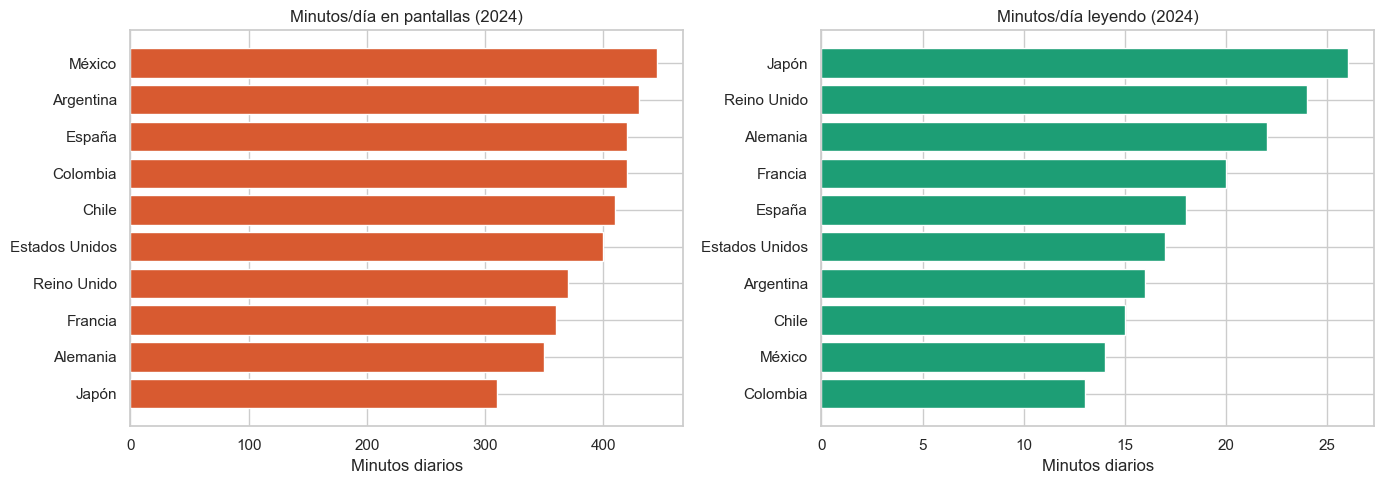

In [22]:
# Distribución del tiempo total en pantallas por país (último año disponible)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pantallas
latest_screen_sorted = latest_screen.sort_values("avg_daily_total_screen_min", ascending=True)
axes[0].barh(latest_screen_sorted["country"], latest_screen_sorted["avg_daily_total_screen_min"],
             color=PALETTE["coral"])
axes[0].set_title("Minutos/día en pantallas (2024)", fontsize=12)
axes[0].set_xlabel("Minutos diarios")

# Lectura
latest_reading = df_reading[df_reading["year"] == df_reading["year"].max()]
latest_reading_sorted = latest_reading.sort_values("avg_daily_reading_min", ascending=True)
axes[1].barh(latest_reading_sorted["country"], latest_reading_sorted["avg_daily_reading_min"],
             color=PALETTE["teal"])
axes[1].set_title("Minutos/día leyendo (2024)", fontsize=12)
axes[1].set_xlabel("Minutos diarios")

plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "assets" / "eda_comparativa_2024.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Análisis comparativo — Lectura vs. tiempo en pantallas por país

In [23]:
# Combinar datasets para el año más reciente
df_combined = pd.merge(
    latest_screen[["country", "avg_daily_total_screen_min", "avg_daily_social_media_min"]],
    latest_reading[["country", "avg_daily_reading_min", "pct_reads_regularly", "avg_books_per_year"]],
    on="country"
)
df_combined["ratio_screen_vs_reading"] = (
    df_combined["avg_daily_total_screen_min"] / df_combined["avg_daily_reading_min"]
).round(1)

print("Ratio pantallas/lectura por país:")
df_combined[["country", "avg_daily_total_screen_min", "avg_daily_reading_min",
             "ratio_screen_vs_reading"]].sort_values("ratio_screen_vs_reading", ascending=False)

Ratio pantallas/lectura por país:


,country,avg_daily_total_screen_min,avg_daily_reading_min,ratio_screen_vs_reading
3,Colombia,420,13,32.3
1,México,445,14,31.8
4,Chile,410,15,27.3
2,Argentina,430,16,26.9
8,Estados Unidos,400,17,23.5
0,España,420,18,23.3
6,Francia,360,20,18.0
5,Alemania,350,22,15.9
7,Reino Unido,370,24,15.4
9,Japón,310,26,11.9


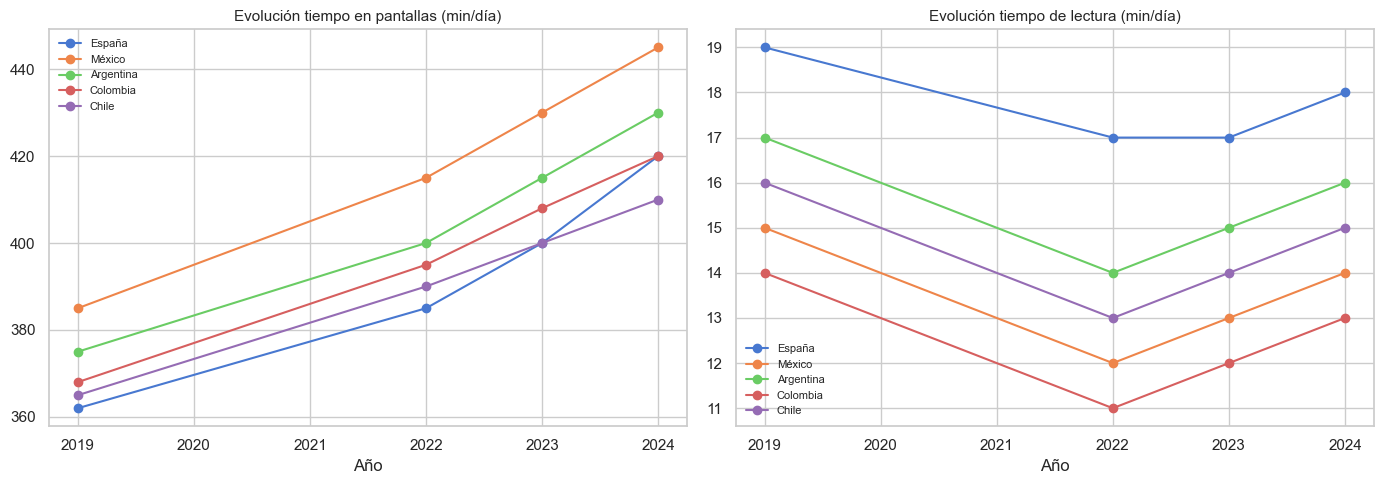

In [24]:
# Evolución temporal: lectura vs. pantallas (países de habla hispana)
hispana = ["España", "México", "Argentina", "Colombia", "Chile"]
screen_trend = df_screen[df_screen["country"].isin(hispana)]
reading_trend = df_reading[df_reading["country"].isin(hispana)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for country in hispana:
    s = screen_trend[screen_trend["country"] == country].sort_values("year")
    r = reading_trend[reading_trend["country"] == country].sort_values("year")
    axes[0].plot(s["year"], s["avg_daily_total_screen_min"], marker="o", label=country)
    axes[1].plot(r["year"], r["avg_daily_reading_min"], marker="o", label=country)

axes[0].set_title("Evolución tiempo en pantallas (min/día)", fontsize=11)
axes[0].legend(fontsize=8)
axes[0].set_xlabel("Año")
axes[1].set_title("Evolución tiempo de lectura (min/día)", fontsize=11)
axes[1].legend(fontsize=8)
axes[1].set_xlabel("Año")

plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "assets" / "eda_evolucion_hispana.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Correlaciones cognitivas

Visualizamos los hallazgos de los estudios científicos: qué métricas cognitivas mejoran con la lectura habitual y en qué magnitud.

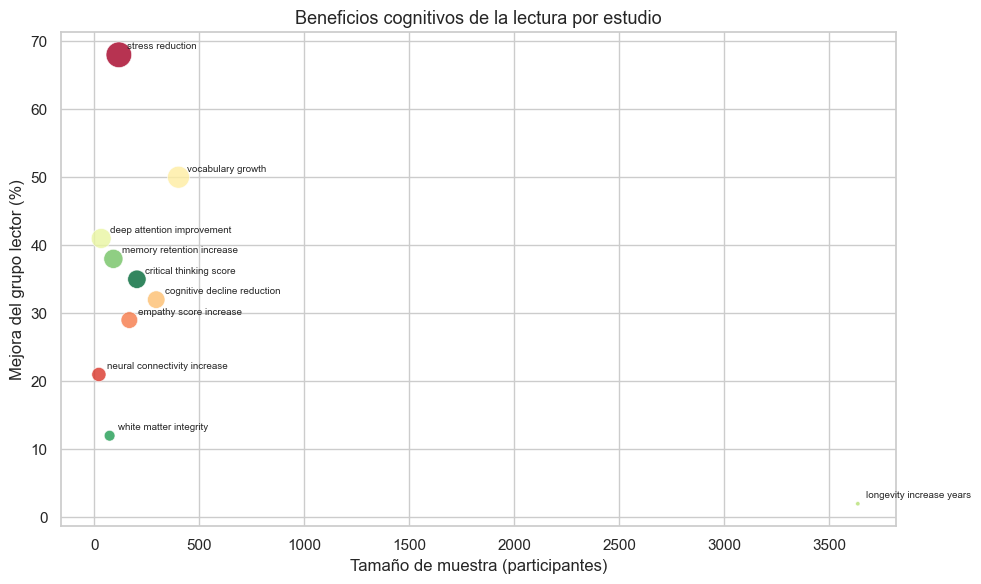

In [25]:
# Scatter: mejora vs. tamaño de muestra
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_cog["sample_size"],
    df_cog["reading_group_value"],
    s=df_cog["reading_group_value"] * 5,
    c=range(len(df_cog)),
    cmap="RdYlGn",
    alpha=0.8,
    edgecolors="white",
    linewidths=0.5,
)

for _, row in df_cog.iterrows():
    ax.annotate(
        row["metric"].replace("_", " "),
        (row["sample_size"], row["reading_group_value"]),
        fontsize=7,
        xytext=(6, 4),
        textcoords="offset points",
    )

ax.set_title("Beneficios cognitivos de la lectura por estudio", fontsize=13)
ax.set_xlabel("Tamaño de muestra (participantes)")
ax.set_ylabel("Mejora del grupo lector (%)")
plt.tight_layout()
plt.savefig(ROOT / "dashboard" / "assets" / "eda_cognitive_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

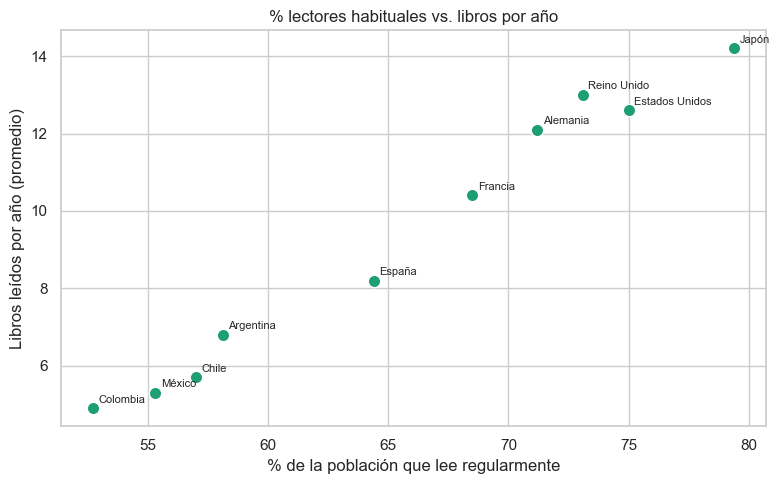

In [26]:
# Correlación entre lectura habitual y número de libros por país (2024)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    df_combined["pct_reads_regularly"],
    df_combined["avg_books_per_year"],
    color=PALETTE["teal"],
    s=80,
    edgecolors="white",
)
for _, row in df_combined.iterrows():
    ax.annotate(row["country"], (row["pct_reads_regularly"], row["avg_books_per_year"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_title("% lectores habituales vs. libros por año", fontsize=12)
ax.set_xlabel("% de la población que lee regularmente")
ax.set_ylabel("Libros leídos por año (promedio)")
plt.tight_layout()
plt.show()

## 6. Exportación — datos procesados a `data/processed/`

In [27]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df_screen.to_csv(PROCESSED_DIR / "screen_time.csv", index=False)
df_reading.to_csv(PROCESSED_DIR / "reading_habits.csv", index=False)
df_cog.to_csv(PROCESSED_DIR / "cognitive_studies.csv", index=False)
df_combined.to_csv(PROCESSED_DIR / "combined_2024.csv", index=False)

print("✅ Datos exportados a data/processed/:")
for f in PROCESSED_DIR.iterdir():
    print(f"   {f.name}")

✅ Datos exportados a data/processed/:
   attention_studies.csv
   cognitive_studies.csv
   combined_2024.csv
   reading_by_generation.csv
   reading_habits.csv
   screen_time.csv
   sleep_studies.csv


## 7. Síntesis de insights para el Día del Libro

Esta sección destila los hallazgos del análisis en cifras listas para comunicar. Cada cifra proviene del dataset procesado y se recalcula en vivo (no se hardcodea).

In [28]:
# Foco España 2024 + ranking hispano + impacto de recuperar minutos
esp = df_combined[df_combined['country']=='España'].iloc[0]
ratio_esp = esp['avg_daily_total_screen_min'] / esp['avg_daily_reading_min']

# Evolución RRSS España 2019-2024
e19 = df_screen[(df_screen.country=='España') & (df_screen.year==2019)].iloc[0]
e24 = df_screen[(df_screen.country=='España') & (df_screen.year==2024)].iloc[0]
delta_rrss = e24['avg_daily_social_media_min'] - e19['avg_daily_social_media_min']
delta_rrss_pct = delta_rrss / e19['avg_daily_social_media_min'] * 100

# Recuperar 30 min/día → libros
def books(mins, pages=300, mpp=2):
    return mins * 365 / (pages * mpp)

print('=== FOCO ESPAÑA 2024 ===')
print(f"Pantallas: {esp['avg_daily_total_screen_min']:.0f} min ({esp['avg_daily_total_screen_min']/60:.1f} h) vs Lectura: {esp['avg_daily_reading_min']:.0f} min")
print(f"Por cada minuto que España lee, pasa {ratio_esp:.0f} min en pantallas")
print(f"Redes sociales: +{delta_rrss:.0f} min/día desde 2019 (+{delta_rrss_pct:.0f}%)")
print(f"Tiempo de lectura: {e19['avg_daily_total_screen_min']:.0f} → {e24['avg_daily_total_screen_min']:.0f} min (pantallas) | lectura casi plana")

print('\n=== IMPACTO DE RECUPERAR MINUTOS ===')
for m in [10, 20, 30, 60]:
    print(f"Recuperar {m} min/día de scroll → {books(m):.0f} libros/año leídos (300 pág, 2 min/pág)")

print('\n=== RANKING HISPANO 2024 — ratio pantallas/lectura ===')
hisp = df_combined[df_combined.country.isin(['España','México','Argentina','Colombia','Chile'])].copy()
hisp = hisp.sort_values('ratio_screen_vs_reading', ascending=False)
print(hisp[['country','avg_daily_total_screen_min','avg_daily_reading_min','ratio_screen_vs_reading']].to_string(index=False))

print('\n=== EFECTOS COGNITIVOS CITADOS (top 5 por muestra) ===')
top = df_cog.sort_values('sample_size', ascending=False).head(5)
for _, r in top.iterrows():
    print(f"{r['institution']} ({r['year']}) — {r['metric']}: +{r['reading_group_value']:.0f} {r['unit']} (n={r['sample_size']})")

=== FOCO ESPAÑA 2024 ===
Pantallas: 420 min (7.0 h) vs Lectura: 18 min
Por cada minuto que España lee, pasa 23 min en pantallas
Redes sociales: +38 min/día desde 2019 (+63%)
Tiempo de lectura: 362 → 420 min (pantallas) | lectura casi plana

=== IMPACTO DE RECUPERAR MINUTOS ===
Recuperar 10 min/día de scroll → 6 libros/año leídos (300 pág, 2 min/pág)
Recuperar 20 min/día de scroll → 12 libros/año leídos (300 pág, 2 min/pág)
Recuperar 30 min/día de scroll → 18 libros/año leídos (300 pág, 2 min/pág)
Recuperar 60 min/día de scroll → 36 libros/año leídos (300 pág, 2 min/pág)

=== RANKING HISPANO 2024 — ratio pantallas/lectura ===
  country  avg_daily_total_screen_min  avg_daily_reading_min  ratio_screen_vs_reading
 Colombia                         420                     13                     32.3
   México                         445                     14                     31.8
    Chile                         410                     15                     27.3
Argentina              

### 7.1 Mensajes clave (para divulgación Día del Libro)

- **España 2024:** 7 horas frente a pantallas, 18 minutos leyendo. El ratio es ≈ 23:1.
- **2019 → 2024:** el tiempo en redes sociales en España ha crecido +63 % mientras la lectura diaria casi no se ha movido.
- **Efecto 6 minutos:** una sesión breve de lectura reduce marcadores de estrés un 68 % (University of Sussex, 2009).
- **Recuperar 30 min/día de scroll = 18 libros al año** (300 páginas, 2 min/página).
- **Japón lidera lectura** (26 min/día, 14 libros/año), **México lidera pantallas** (445 min/día).

> Importante: los datos de pantallas y lectura son medias nacionales autorreportadas; las cifras cognitivas son grupos experimentales de laboratorio. No se deben comparar directamente las magnitudes de ambos tipos de datos.

In [29]:
import json
from itertools import product
from pathlib import Path

import pandas as pd

# Parametros de formula (se recalculan aqui para que el bloque sea autocontenido).
def get_processed_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "processed").exists():
        return cwd / "data" / "processed"
    if (cwd.parent / "data" / "processed").exists():
        return cwd.parent / "data" / "processed"
    raise FileNotFoundError("No se encontro data/processed en cwd ni en el directorio padre.")

processed_dir = get_processed_data_dir()
combined_2024 = pd.read_csv(processed_dir / "combined_2024.csv")

base_daily_scroll_minutes = float(combined_2024["avg_daily_social_media_min"].mean())
avg_daily_reading_min = float(combined_2024["avg_daily_reading_min"].mean())
avg_books_per_year = float(combined_2024["avg_books_per_year"].mean())
minutes_to_pages = 1.0
avg_pages_per_book = (avg_daily_reading_min * 365 * minutes_to_pages) / avg_books_per_year

arquetipos = [
    {
        "id": "escapista-politica",
        "nombre": "Escapista Politica",
        "descripcion": "Usa la ficcion para ensayar mundos posibles y leer el poder desde fuera.",
        "motivacion_principal": "Entender el mundo a traves de tramas simbolicas.",
        "libros_que_ama": ["distopia", "realismo magico", "ficcion literaria con tension politica"],
        "justificacion": "Convierte ocio digital en imaginacion critica: menos ruido, mas marco mental.",
    },
    {
        "id": "exploradora-empatica",
        "nombre": "Exploradora Empatica",
        "descripcion": "Lee para ampliar sensibilidad, lenguaje emocional y perspectiva humana.",
        "motivacion_principal": "Reconocerse en otras vidas y complejizar su mirada.",
        "libros_que_ama": ["narrativa intima", "memoir", "novela contemporanea"],
        "justificacion": "Encaja con evidencia de lectura como entrenamiento de empatia y atencion sostenida.",
    },
    {
        "id": "lectora-politica",
        "nombre": "Lectora Politica",
        "descripcion": "Busca criterio, contexto y estructura para no pensar en automatico.",
        "motivacion_principal": "Construir pensamiento propio frente a la economia de la distraccion.",
        "libros_que_ama": ["ensayo", "historia", "no ficcion de sistemas"],
        "justificacion": "Traducir minutos recuperados a lectura larga fortalece autonomia cognitiva.",
    },
    {
        "id": "aventurera-reflexiva",
        "nombre": "Aventurera Reflexiva",
        "descripcion": "Necesita ritmo narrativo, pero quiere cerrar cada libro con una idea nueva.",
        "motivacion_principal": "Combinar adrenalina narrativa con aprendizaje personal.",
        "libros_que_ama": ["thriller", "mystery", "aventura con capa filosofica"],
        "justificacion": "Ideal para convertir habito de scroll en ritual lector con recompensa inmediata.",
    },
    {
        "id": "archivista-de-lo-real",
        "nombre": "Archivista de lo Real",
        "descripcion": "Le interesan historias verdaderas para leer la epoca en primera persona.",
        "motivacion_principal": "Comprender vidas reales, memoria y conflicto social.",
        "libros_que_ama": ["cronica", "periodismo narrativo", "biografia"],
        "justificacion": "Sostiene una lectura anclada en hechos para recuperar orientacion y criterio publico.",
    },
]

print("CELDA 1 - ARQUETIPOS + JUSTIFICACION\n")
for i, a in enumerate(arquetipos, start=1):
    print(f"{i}. {a['nombre']} ({a['id']})")
    print(f"   - Descripcion: {a['descripcion']}")
    print(f"   - Motivacion: {a['motivacion_principal']}")
    print(f"   - Ama leer: {', '.join(a['libros_que_ama'])}")
    print(f"   - Justificacion: {a['justificacion']}\n")

print("Parametros de formula (base del analisis):")
print(f"- base_daily_scroll_minutes: {base_daily_scroll_minutes:.1f}")
print(f"- avg_pages_per_book (calibrado): {avg_pages_per_book:.2f}")

CELDA 1 - ARQUETIPOS + JUSTIFICACION

1. Escapista Politica (escapista-politica)
   - Descripcion: Usa la ficcion para ensayar mundos posibles y leer el poder desde fuera.
   - Motivacion: Entender el mundo a traves de tramas simbolicas.
   - Ama leer: distopia, realismo magico, ficcion literaria con tension politica
   - Justificacion: Convierte ocio digital en imaginacion critica: menos ruido, mas marco mental.

2. Exploradora Empatica (exploradora-empatica)
   - Descripcion: Lee para ampliar sensibilidad, lenguaje emocional y perspectiva humana.
   - Motivacion: Reconocerse en otras vidas y complejizar su mirada.
   - Ama leer: narrativa intima, memoir, novela contemporanea
   - Justificacion: Encaja con evidencia de lectura como entrenamiento de empatia y atencion sostenida.

3. Lectora Politica (lectora-politica)
   - Descripcion: Busca criterio, contexto y estructura para no pensar en automatico.
   - Motivacion: Construir pensamiento propio frente a la economia de la distraccion

In [30]:
# Matriz quiz -> arquetipos (todas las combinaciones posibles con las opciones dadas).
# Nota: con 4 opciones por pregunta, el total matematico es 4 x 4 x 4 = 64.

pregunta_1 = {
    "texto": "Cual es tu relacion con la lectura?",
    "opciones": {
        "ESC": "Escapo del ruido",
        "ENT": "Busco entender el mundo",
        "EXP": "Exploro sentimientos",
        "REA": "Me pierdo en historias reales",
    },
}

pregunta_2 = {
    "texto": "Cuanto tiempo quieres invertir por libro?",
    "opciones": {
        "COR": "Corto y potente (<150 pags)",
        "MED": "A ritmo tranquilo (150-300 pags)",
        "LAR": "Inmersion profunda (>300 pags)",
        "VAR": "Depende del libro",
    },
}

pregunta_3 = {
    "texto": "Que buscas al leer?",
    "opciones": {
        "CRI": "Criterio",
        "CON": "Conexion",
        "BEL": "Belleza",
        "AVE": "Aventura",
    },
}

scores_p1 = {
    "ESC": {"escapista-politica": 3, "aventurera-reflexiva": 1},
    "ENT": {"lectora-politica": 3, "archivista-de-lo-real": 1},
    "EXP": {"exploradora-empatica": 3, "escapista-politica": 1},
    "REA": {"archivista-de-lo-real": 3, "lectora-politica": 1},
}

scores_p2 = {
    "COR": {"archivista-de-lo-real": 2, "aventurera-reflexiva": 1},
    "MED": {"exploradora-empatica": 2, "aventurera-reflexiva": 1},
    "LAR": {"lectora-politica": 2, "escapista-politica": 1},
    "VAR": {"aventurera-reflexiva": 2, "escapista-politica": 1},
}

scores_p3 = {
    "CRI": {"lectora-politica": 3, "archivista-de-lo-real": 1},
    "CON": {"exploradora-empatica": 3, "archivista-de-lo-real": 1},
    "BEL": {"escapista-politica": 3, "exploradora-empatica": 1},
    "AVE": {"aventurera-reflexiva": 3, "escapista-politica": 1},
}

priority = [
    "lectora-politica",
    "escapista-politica",
    "exploradora-empatica",
    "archivista-de-lo-real",
    "aventurera-reflexiva",
]


def asignar_arquetipo(c1: str, c2: str, c3: str) -> str:
    acc = {a["id"]: 0 for a in arquetipos}
    for source in (scores_p1[c1], scores_p2[c2], scores_p3[c3]):
        for k, v in source.items():
            acc[k] += v
    best = sorted(acc.items(), key=lambda kv: (kv[1], -priority.index(kv[0])), reverse=True)[0][0]
    return best

rows = []
correspondencias = {}

for c1, c2, c3 in product(pregunta_1["opciones"].keys(), pregunta_2["opciones"].keys(), pregunta_3["opciones"].keys()):
    archetype_id = asignar_arquetipo(c1, c2, c3)
    key = f"{c1}_{c2}_{c3}"
    correspondencias[key] = archetype_id
    rows.append(
        {
            "combo": key,
            "p1": pregunta_1["opciones"][c1],
            "p2": pregunta_2["opciones"][c2],
            "p3": pregunta_3["opciones"][c3],
            "arquetipo_id": archetype_id,
        }
    )

quiz_matrix_df = pd.DataFrame(rows)

print(f"CELDA 2 - MATRIZ QUIZ: {len(quiz_matrix_df)} combinaciones generadas.")
print("Con las opciones actuales no son 81, son 64 (4x4x4).")
quiz_matrix_df.head(12)

CELDA 2 - MATRIZ QUIZ: 64 combinaciones generadas.
Con las opciones actuales no son 81, son 64 (4x4x4).


,combo,p1,p2,p3,arquetipo_id
0,ESC_COR_CRI,Escapo del ruido,Corto y potente (<150 pags),Criterio,lectora-politica
1,ESC_COR_CON,Escapo del ruido,Corto y potente (<150 pags),Conexion,escapista-politica
2,ESC_COR_BEL,Escapo del ruido,Corto y potente (<150 pags),Belleza,escapista-politica
3,ESC_COR_AVE,Escapo del ruido,Corto y potente (<150 pags),Aventura,aventurera-reflexiva
4,ESC_MED_CRI,Escapo del ruido,A ritmo tranquilo (150-300 pags),Criterio,lectora-politica
5,ESC_MED_CON,Escapo del ruido,A ritmo tranquilo (150-300 pags),Conexion,exploradora-empatica
6,ESC_MED_BEL,Escapo del ruido,A ritmo tranquilo (150-300 pags),Belleza,escapista-politica
7,ESC_MED_AVE,Escapo del ruido,A ritmo tranquilo (150-300 pags),Aventura,aventurera-reflexiva
8,ESC_LAR_CRI,Escapo del ruido,Inmersion profunda (>300 pags),Criterio,lectora-politica
9,ESC_LAR_CON,Escapo del ruido,Inmersion profunda (>300 pags),Conexion,escapista-politica


In [31]:
# Base editorial de recomendaciones por arquetipo.
pages_per_hour = 45.0

books_by_archetype_seed = {
    "escapista-politica": [
        ("1984", "George Orwell", 328, "Distopia", "Ficcion sobre vigilancia, poder y lenguaje como disputa politica."),
        ("Fahrenheit 451", "Ray Bradbury", 194, "Distopia", "Pregunta quien controla lo que merece ser leido."),
        ("El cuento de la criada", "Margaret Atwood", 311, "Distopia", "Muestra como el poder coloniza cuerpo, memoria y deseo."),
        ("La mano izquierda de la oscuridad", "Ursula K. Le Guin", 304, "Ciencia ficcion", "Ensaya politica, identidad y convivencia en otro orden social."),
        ("Cadaver exquisito", "Agustina Bazterrica", 256, "Distopia contemporanea", "Alegoria feroz sobre consumo, violencia y normalizacion."),
    ],
    "exploradora-empatica": [
        ("Los asquerosos", "Santiago Lorenzo", 224, "Novela contemporanea", "Humor y vulnerabilidad para pensar formas de vida alternativas."),
        ("Nada", "Carmen Laforet", 296, "Clasico contemporaneo", "Retrato emocional de juventud, precariedad y busqueda de voz propia."),
        ("Ordesa", "Manuel Vilas", 336, "Memoir", "Duelo, memoria familiar y ternura sin sentimentalismo."),
        ("El infinito en un junco", "Irene Vallejo", 464, "Ensayo narrativo", "Defensa sensible de la lectura como continuidad historica."),
        ("Pequenas cosas como estas", "Claire Keegan", 128, "Novela corta", "Minimalismo emocional con gran potencia moral."),
    ],
    "lectora-politica": [
        ("Caliban y la bruja", "Silvia Federici", 416, "Ensayo", "Historia material del poder sobre cuerpos y trabajo."),
        ("Vigilar y castigar", "Michel Foucault", 360, "Ensayo", "Cartografia de instituciones, disciplina y control social."),
        ("La sociedad del cansancio", "Byung-Chul Han", 128, "Ensayo breve", "Lectura critica de rendimiento, fatiga y autoexplotacion."),
        ("Las venas abiertas de America Latina", "Eduardo Galeano", 400, "Historia critica", "Relaciona economia, memoria y dependencia regional."),
        ("No logo", "Naomi Klein", 560, "No ficcion", "Desmonta la logica cultural y economica de las marcas globales."),
    ],
    "aventurera-reflexiva": [
        ("El nombre de la rosa", "Umberto Eco", 736, "Misterio historico", "Suspense intelectual sobre verdad, poder y archivo."),
        ("La verdad sobre el caso Harry Quebert", "Joel Dicker", 672, "Thriller", "Ritmo adictivo con reflexion sobre escritura y fama."),
        ("Patria", "Fernando Aramburu", 648, "Narrativa contemporanea", "Tension narrativa y lectura etica del conflicto."),
        ("Perdida", "Gillian Flynn", 576, "Thriller psicologico", "Juega con narradores y fabrica de relatos en la esfera publica."),
        ("Los hombres que no amaban a las mujeres", "Stieg Larsson", 672, "Misterio", "Investigacion, periodismo y violencia estructural."),
    ],
    "archivista-de-lo-real": [
        ("A sangre fria", "Truman Capote", 368, "Cronica", "Modelo de no ficcion narrativa para leer crimen y sociedad."),
        ("Los suicidas del fin del mundo", "Leila Guerriero", 256, "Periodismo narrativo", "Escucha profunda de una comunidad en crisis."),
        ("El director", "David Jimenez", 320, "Memoir periodistico", "Radiografia del poder mediatico y sus pactos."),
        ("Hiroshima", "John Hersey", 176, "Cronica historica", "Seis vidas reales para entender un trauma global."),
        ("La ridicula idea de no volver a verte", "Rosa Montero", 240, "No ficcion intima", "Cruza biografia, duelo y memoria cultural."),
    ],
}

books_by_archetype = {}
for archetype_id, books in books_by_archetype_seed.items():
    formatted = []
    for title, author, pages, genre, why_here in books:
        formatted.append(
            {
                "titulo": title,
                "autor": author,
                "paginas": pages,
                "genero": genre,
                "horas_estimadas": round(pages / pages_per_hour, 1),
                "por_que_aqui": why_here,
            }
        )
    books_by_archetype[archetype_id] = formatted

print("CELDA 3 - BASE DE LIBROS POR ARQUETIPO (JSON)")
print(json.dumps(books_by_archetype, ensure_ascii=False, indent=2))

CELDA 3 - BASE DE LIBROS POR ARQUETIPO (JSON)
{
  "escapista-politica": [
    {
      "titulo": "1984",
      "autor": "George Orwell",
      "paginas": 328,
      "genero": "Distopia",
      "horas_estimadas": 7.3,
      "por_que_aqui": "Ficcion sobre vigilancia, poder y lenguaje como disputa politica."
    },
    {
      "titulo": "Fahrenheit 451",
      "autor": "Ray Bradbury",
      "paginas": 194,
      "genero": "Distopia",
      "horas_estimadas": 4.3,
      "por_que_aqui": "Pregunta quien controla lo que merece ser leido."
    },
    {
      "titulo": "El cuento de la criada",
      "autor": "Margaret Atwood",
      "paginas": 311,
      "genero": "Distopia",
      "horas_estimadas": 6.9,
      "por_que_aqui": "Muestra como el poder coloniza cuerpo, memoria y deseo."
    },
    {
      "titulo": "La mano izquierda de la oscuridad",
      "autor": "Ursula K. Le Guin",
      "paginas": 304,
      "genero": "Ciencia ficcion",
      "horas_estimadas": 6.8,
      "por_que_aqui": "En

In [32]:
# JSON final listo para Stitch/React.
arquetipos_final = []
for a in arquetipos:
    arquetipos_final.append(
        {
            "id": a["id"],
            "nombre": a["nombre"],
            "descripcion": a["descripcion"],
            "motivacion_principal": a["motivacion_principal"],
            "libros_que_ama": a["libros_que_ama"],
            "libros": books_by_archetype[a["id"]],
        }
    )

final_payload = {
    "arquetipos": arquetipos_final,
    "quiz_logic": {
        "pregunta_1": pregunta_1,
        "pregunta_2": pregunta_2,
        "pregunta_3": pregunta_3,
        "combinaciones_totales": len(correspondencias),
        "correspondencias": correspondencias,
    },
    "formula_lectura": {
        "base_daily_scroll_minutes": round(base_daily_scroll_minutes, 1),
        "minutes_to_pages": minutes_to_pages,
        "avg_pages_per_book": round(avg_pages_per_book, 2),
        "minutos_a_horas_anuales": "(X * 365) / 60",
        "horas_a_libros": "((X * 365) / 60) / horas_promedio_libro",
        "minutos_a_libros_directa": "(X * 365 * minutes_to_pages) / avg_pages_per_book",
    },
}

final_payload_json = json.dumps(final_payload, ensure_ascii=False, indent=2)
print("CELDA 4 - JSON FINAL COPIABLE\n")
print(final_payload_json)

CELDA 4 - JSON FINAL COPIABLE

{
  "arquetipos": [
    {
      "id": "escapista-politica",
      "nombre": "Escapista Politica",
      "descripcion": "Usa la ficcion para ensayar mundos posibles y leer el poder desde fuera.",
      "motivacion_principal": "Entender el mundo a traves de tramas simbolicas.",
      "libros_que_ama": [
        "distopia",
        "realismo magico",
        "ficcion literaria con tension politica"
      ],
      "libros": [
        {
          "titulo": "1984",
          "autor": "George Orwell",
          "paginas": 328,
          "genero": "Distopia",
          "horas_estimadas": 7.3,
          "por_que_aqui": "Ficcion sobre vigilancia, poder y lenguaje como disputa politica."
        },
        {
          "titulo": "Fahrenheit 451",
          "autor": "Ray Bradbury",
          "paginas": 194,
          "genero": "Distopia",
          "horas_estimadas": 4.3,
          "por_que_aqui": "Pregunta quien controla lo que merece ser leido."
        },
        {

In [33]:
# Ejemplos de chains quiz -> arquetipo -> libros sugeridos

examples = [
    ["ESC", "MED", "CRI"],
    ["ENT", "LAR", "CRI"],
    ["EXP", "MED", "CON"],
    ["REA", "COR", "CON"],
    ["ESC", "VAR", "AVE"],
]

id_to_name = {a["id"]: a["nombre"] for a in arquetipos}

print("CELDA 5 - EJEMPLOS DE CHAINS\n")
for c1, c2, c3 in examples:
    key = f"{c1}_{c2}_{c3}"
    archetype_id = correspondencias[key]
    archetype_name = id_to_name[archetype_id]
    recs = books_by_archetype[archetype_id][:3]
    rec_titles = ", ".join([f"{b['titulo']} ({b['autor']})" for b in recs])

    print(f"Quiz [{c1}, {c2}, {c3}] -> {archetype_name} ({archetype_id})")
    print(f"  Recomendaciones iniciales: {rec_titles}\n")

CELDA 5 - EJEMPLOS DE CHAINS

Quiz [ESC, MED, CRI] -> Lectora Politica (lectora-politica)
  Recomendaciones iniciales: Caliban y la bruja (Silvia Federici), Vigilar y castigar (Michel Foucault), La sociedad del cansancio (Byung-Chul Han)

Quiz [ENT, LAR, CRI] -> Lectora Politica (lectora-politica)
  Recomendaciones iniciales: Caliban y la bruja (Silvia Federici), Vigilar y castigar (Michel Foucault), La sociedad del cansancio (Byung-Chul Han)

Quiz [EXP, MED, CON] -> Exploradora Empatica (exploradora-empatica)
  Recomendaciones iniciales: Los asquerosos (Santiago Lorenzo), Nada (Carmen Laforet), Ordesa (Manuel Vilas)

Quiz [REA, COR, CON] -> Archivista de lo Real (archivista-de-lo-real)
  Recomendaciones iniciales: A sangre fria (Truman Capote), Los suicidas del fin del mundo (Leila Guerriero), El director (David Jimenez)

Quiz [ESC, VAR, AVE] -> Aventurera Reflexiva (aventurera-reflexiva)
  Recomendaciones iniciales: El nombre de la rosa (Umberto Eco), La verdad sobre el caso Harry Qu

## 8) React App Build Pack: Lectura = Poder

### Celda 1: Estructura de carpetas + dependencias

```text
src/
  components/
    Hero.jsx
    Slider.jsx
    Quiz.jsx
    Result.jsx
    Card.jsx
  data/
    reading-power.json
  App.jsx
  App.css
  main.jsx
```

```json
{
  "name": "lectura-poder-app",
  "private": true,
  "version": "0.1.0",
  "type": "module",
  "scripts": {
    "dev": "vite",
    "build": "vite build",
    "preview": "vite preview"
  },
  "dependencies": {
    "react": "^18.3.1",
    "react-dom": "^18.3.1",
    "framer-motion": "^11.11.17",
    "html2canvas": "^1.4.1"
  },
  "devDependencies": {
    "vite": "^5.4.10",
    "@vitejs/plugin-react": "^4.3.2"
  }
}
```

```bash
# Si quieres usar Tailwind (opcional)
npm install -D tailwindcss postcss autoprefixer
npx tailwindcss init -p
```

Nota: en tu JSON actual del notebook, las correspondencias del quiz son 64 (4x4x4), no 16^3.

In [ ]:
// Celda 2: App.jsx (Componente principal)
import React, { useMemo, useState } from 'react';
import data from './data/reading-power.json';
import Hero from './components/Hero';
import Slider from './components/Slider';
import Quiz from './components/Quiz';
import Result from './components/Result';
import './App.css';

const QUIZ_ORDER = ['pregunta_1', 'pregunta_2', 'pregunta_3'];

function getQuizCode(answers) {
  return answers.join('_');
}

function computeNumbers(sliderValue, formula) {
  const horas = Number(((sliderValue * 365) / 60).toFixed(1));
  const dias = Number((horas / 24).toFixed(1));

  // Formula recomendada por tu notebook:
  // libros = (X * 365 * minutes_to_pages) / avg_pages_per_book
  const booksRaw =
    (sliderValue * 365 * formula.minutes_to_pages) / formula.avg_pages_per_book;
  const libros = Number(booksRaw.toFixed(1));

  return { horas, dias, libros };
}

export default function App() {
  const [step, setStep] = useState('hero'); // hero | slider | quiz | result
  const [sliderValue, setSliderValue] = useState(60);
  const [quizAnswers, setQuizAnswers] = useState([null, null, null]); // codigos: ESC/MED/CRI...

  const quizData = data.quiz_logic;

  const result = useMemo(() => {
    if (quizAnswers.includes(null)) return null;

    const codigo = getQuizCode(quizAnswers);
    const arquetipoId = quizData.correspondencias[codigo];
    const arquetipo = data.arquetipos.find((a) => a.id === arquetipoId);

    if (!arquetipo) return null;

    const { horas, dias, libros } = computeNumbers(sliderValue, data.formula_lectura);

    return {
      codigo,
      arquetipo,
      horas,
      dias,
      libros,
      libros_recomendados: arquetipo.libros || [],
    };
  }, [quizAnswers, sliderValue, quizData]);

  const restart = () => {
    setQuizAnswers([null, null, null]);
    setSliderValue(60);
    setStep('hero');
  };

  return (
    <div className="app-shell">
      {step === 'hero' && <Hero onStart={() => setStep('slider')} />}

      {step === 'slider' && (
        <Slider
          value={sliderValue}
          onChange={setSliderValue}
          onNext={() => setStep('quiz')}
          formula={data.formula_lectura}
        />
      )}

      {step === 'quiz' && (
        <Quiz
          quizLogic={quizData}
          quizOrder={QUIZ_ORDER}
          answers={quizAnswers}
          setAnswers={setQuizAnswers}
          onFinish={() => setStep('result')}
          onBack={() => setStep('slider')}
        />
      )}

      {step === 'result' && (
        <Result
          data={result}
          sliderValue={sliderValue}
          onRestart={restart}
          onBackQuiz={() => setStep('quiz')}
        />
      )}
    </div>
  );
}

In [ ]:
// Celda 3: Slider.jsx
import React, { useMemo } from 'react';
import { motion } from 'framer-motion';

function computeNumbers(value, formula) {
  const horas = Number(((value * 365) / 60).toFixed(1));
  const dias = Number((horas / 24).toFixed(1));
  const libros = Number(
    ((value * 365 * formula.minutes_to_pages) / formula.avg_pages_per_book).toFixed(1)
  );
  return { horas, dias, libros };
}

function impactCopy(value) {
  if (value === 0) return 'Punto cero: el algoritmo decide por ti.';
  if (value <= 30) return 'Empiezas a recuperar una semana de criterio propio.';
  if (value <= 60) return 'Ya es medio mes al año para leer fuera del ruido.';
  if (value <= 120) return 'Aquí recuperas un mes completo de atención consciente.';
  return 'Esto no es productividad: es soberanía sobre tu tiempo.';
}

export default function Slider({ value, onChange, onNext, formula }) {
  const result = useMemo(() => computeNumbers(value, formula), [value, formula]);

  return (
    <section className="slider-section container">
      <h2>¿Cuánto tiempo te roban? ¿Cuánto puedes reclamar?</h2>
      <p className="subtitle">Lectura es ganar criterio y poder de elección.</p>

      <div className="slider-card">
        <label htmlFor="scroll-range">Minutos diarios en redes que puedes reclamar</label>
        <input
          id="scroll-range"
          className="slider"
          type="range"
          min="0"
          max="180"
          step="15"
          value={value}
          onChange={(e) => onChange(Number(e.target.value))}
        />
        <div className="slider-labels">
          <span>0 min</span>
          <strong>{value} min</strong>
          <span>180 min</span>
        </div>
      </div>

      <motion.div
        className="result-preview"
        initial={{ opacity: 0, y: 10 }}
        animate={{ opacity: 1, y: 0 }}
        transition={{ duration: 0.25 }}
      >
        <div className="stat">
          <span className="number">{result.horas}</span>
          <span className="label">horas de lectura/año</span>
        </div>
        <div className="stat">
          <span className="number">{result.dias}</span>
          <span className="label">días completos recuperados</span>
        </div>
        <div className="stat">
          <span className="number">~{result.libros}</span>
          <span className="label">libros aproximados</span>
        </div>
      </motion.div>

      <p className="insight">{impactCopy(value)}</p>

      <button className="cta-button" onClick={onNext}>
        Siguiente: Tu perfil lector
      </button>
    </section>
  );
}

In [ ]:
// Celda 4: Quiz.jsx
import React, { useMemo } from 'react';
import { motion, AnimatePresence } from 'framer-motion';

const LETTERS = ['A', 'B', 'C', 'D'];

export default function Quiz({ quizLogic, quizOrder, answers, setAnswers, onFinish, onBack }) {
  const currentIndex = answers.findIndex((a) => a === null);
  const safeIndex = currentIndex === -1 ? quizOrder.length - 1 : currentIndex;
  const currentKey = quizOrder[safeIndex];
  const currentQuestion = quizLogic[currentKey];

  const optionEntries = useMemo(
    () => Object.entries(currentQuestion.opciones),
    [currentQuestion]
  );

  const answerCurrent = (code) => {
    const next = [...answers];
    next[safeIndex] = code;
    setAnswers(next);

    const done = next.every(Boolean);
    if (done) {
      setTimeout(onFinish, 220);
    }
  };

  const progress = ((safeIndex + 1) / quizOrder.length) * 100;

  return (
    <section className="quiz-section container">
      <div className="quiz-top">
        <button className="link-button" onClick={onBack}>← Volver</button>
        <span>Pregunta {safeIndex + 1} de {quizOrder.length}</span>
      </div>

      <div className="progress-bar">
        <div className="progress-fill" style={{ width: `${progress}%` }} />
      </div>

      <AnimatePresence mode="wait">
        <motion.div
          key={currentKey}
          initial={{ opacity: 0, x: 14 }}
          animate={{ opacity: 1, x: 0 }}
          exit={{ opacity: 0, x: -14 }}
          transition={{ duration: 0.22 }}
        >
          <h3>{currentQuestion.texto}</h3>
          <p className="pregunta-subtitle">No hay respuestas incorrectas: solo una forma de leer el mundo.</p>

          <div className="opciones">
            {optionEntries.map(([code, label], idx) => (
              <button
                key={code}
                className={`opcion ${answers[safeIndex] === code ? 'selected' : ''}`}
                onClick={() => answerCurrent(code)}
              >
                <span className="numero">{LETTERS[idx]}</span>
                <span>{label}</span>
              </button>
            ))}
          </div>
        </motion.div>
      </AnimatePresence>
    </section>
  );
}

In [ ]:
// Celda 5: Result.jsx (incluye Card shareable)
import React, { useRef } from 'react';
import html2canvas from 'html2canvas';
import { motion } from 'framer-motion';

function ShareCard({ cardRef, arquetipo, horas, dias, libros, sliderValue }) {
  return (
    <div ref={cardRef} className="card-shareable">
      <p className="card-kicker">LECTURA = PODER</p>
      <h3>Recuperaré {horas} horas de lectura este año.</h3>
      <p>Si reclamo {sliderValue} min/día de scroll.</p>
      <p className="card-arch">Perfil: {arquetipo.nombre}</p>
      <p className="card-metrics">{dias} días completos · ~{libros} libros</p>
      <p className="card-cta">@anaisentrelineas</p>
    </div>
  );
}

export default function Result({ data, sliderValue, onRestart, onBackQuiz }) {
  const cardRef = useRef(null);
  if (!data) return <div className="container">Calculando resultado…</div>;

  const { arquetipo, horas, dias, libros, libros_recomendados } = data;

  const downloadCard = async () => {
    const canvas = await html2canvas(cardRef.current, {
      scale: 2,
      backgroundColor: null,
      useCORS: true,
    });
    const link = document.createElement('a');
    link.href = canvas.toDataURL('image/png');
    link.download = `lectura-poder-${arquetipo.id}.png`;
    link.click();
  };

  return (
    <section className="result-section container">
      <motion.div initial={{ opacity: 0, y: 12 }} animate={{ opacity: 1, y: 0 }}>
        <h2>Tu perfil lector: {arquetipo.nombre}</h2>
        <p>{arquetipo.descripcion}</p>
        <p className="motivacion">{arquetipo.motivacion_principal}</p>

        <div className="numeros">
          <div className="numero-box"><span className="big">{horas}</span><span>horas/año</span></div>
          <div className="numero-box"><span className="big">{dias}</span><span>días completos</span></div>
          <div className="numero-box"><span className="big">~{libros}</span><span>libros aprox.</span></div>
        </div>

        <div className="libros-recomendados">
          <h4>Lecturas recomendadas para ti</h4>
          {libros_recomendados.slice(0, 5).map((libro) => (
            <article key={libro.titulo} className="libro-item">
              <h5>{libro.titulo}</h5>
              <p className="autor">{libro.autor}</p>
              <p className="meta">{libro.paginas} págs · {libro.genero} · {libro.horas_estimadas} h aprox</p>
              <p className="por-que">{libro.por_que_aqui}</p>
            </article>
          ))}
        </div>

        <ShareCard
          cardRef={cardRef}
          arquetipo={arquetipo}
          horas={horas}
          dias={dias}
          libros={libros}
          sliderValue={sliderValue}
        />

        <button className="cta-button" onClick={downloadCard}>Descargar card para Instagram</button>
        <button className="secondary-button" onClick={onBackQuiz}>Ajustar quiz</button>
        <button className="secondary-button" onClick={onRestart}>Empezar de nuevo</button>
      </motion.div>
    </section>
  );
}

In [ ]:
/* Celda 6: App.css (mobile-first) */
:root {
  --teal: #0b6b67;
  --coral: #ff6f61;
  --beige: #efe5d9;
  --sand: #f8f2ea;
  --ink: #151515;
  --paper: #fbf7f1;
}

* { box-sizing: border-box; }
body { margin: 0; background: var(--paper); color: var(--ink); font-family: Georgia, 'Times New Roman', serif; }
.app-shell { min-height: 100vh; }
.container { width: min(760px, calc(100% - 32px)); margin: 0 auto; padding: 24px 0 56px; }

h1,h2,h3,h4,h5 { margin: 0 0 10px; line-height: 1.1; }
p { margin: 0 0 10px; }

.hero-section { padding-top: 44px; }
.hero-section h1 { font-size: clamp(2rem, 8vw, 3.4rem); }
.hero-highlight { color: #b3221f; font-style: italic; }
.subtitle { opacity: 0.85; }

.slider-card, .quiz-section, .result-section { background: var(--beige); border: 1px solid #dfcfbf; border-radius: 16px; padding: 18px; }
.slider { width: 100%; margin-top: 10px; accent-color: var(--coral); }
.slider-labels { display: flex; justify-content: space-between; margin-top: 8px; }

.result-preview, .numeros { display: grid; grid-template-columns: 1fr; gap: 10px; margin: 16px 0; }
.stat, .numero-box { background: white; border-radius: 12px; padding: 12px; text-align: center; border: 1px solid #e6ddd1; }
.number, .big { display: block; font-size: 2rem; color: var(--coral); font-weight: 700; }
.insight { font-style: italic; color: #234; }

.quiz-top { display: flex; justify-content: space-between; align-items: center; margin-bottom: 8px; }
.progress-bar { height: 8px; border-radius: 99px; background: #eadfce; overflow: hidden; margin-bottom: 16px; }
.progress-fill { height: 100%; background: linear-gradient(90deg, #d38a00, var(--coral)); }
.opciones { display: grid; gap: 10px; }
.opcion { display: flex; gap: 10px; align-items: center; width: 100%; border: 1px solid #d3bfb0; background: #fff; padding: 12px; border-radius: 12px; text-align: left; }
.opcion.selected { border-color: var(--coral); background: #fff1ef; }
.numero { width: 32px; height: 32px; border-radius: 999px; display: grid; place-items: center; background: #f2e5d9; color: #b3221f; font-weight: 700; }

.libros-recomendados { margin-top: 14px; }
.libro-item { border-top: 1px dashed #ccb8a8; padding: 10px 0; }
.autor { color: #444; font-style: italic; }
.meta { font-size: 0.92rem; color: #666; }

.card-shareable {
  margin: 18px 0;
  padding: 16px;
  border-radius: 16px;
  background: radial-gradient(circle at top right, #1f9d96, var(--teal));
  color: #fff;
}
.card-kicker { letter-spacing: 0.08em; font-size: 0.8rem; opacity: 0.9; }
.card-arch { font-style: italic; }
.card-cta { opacity: 0.92; }

.cta-button, .secondary-button, .link-button {
  border: 0;
  border-radius: 10px;
  padding: 12px 14px;
  margin-top: 8px;
  cursor: pointer;
}
.cta-button { width: 100%; background: var(--coral); color: #fff; font-weight: 700; }
.secondary-button { width: 100%; background: transparent; border: 1px solid #c3b09f; }
.link-button { background: transparent; text-decoration: underline; padding: 0; }

@media (min-width: 820px) {
  .result-preview, .numeros { grid-template-columns: repeat(3, 1fr); }
}

In [ ]:
# Celda 7: Instalación + export JSON + deploy

# 1) Crear app con Vite
npm create vite@latest lectura-poder -- --template react
cd lectura-poder
npm install

# 2) Dependencias de la app
npm install framer-motion html2canvas

# 3) Copiar JSON exportado del notebook
#    - Copia el contenido de la celda "JSON final copiable"
#    - Guarda como: src/data/reading-power.json

# 4) Crear estructura de componentes
mkdir -p src/components src/data

# 5) Pegar componentes (Hero, Slider, Quiz, Result, Card), App.jsx y App.css

# 6) Levantar entorno local
npm run dev

# 7) Build producción
npm run build

# 8) Deploy (ejemplo Vercel)
npm install -g vercel
vercel

# Nota técnica:
# - En el JSON actual del notebook, quiz_logic.correspondencias contiene 64 combinaciones.
# - Si quieres 81 combinaciones, la pregunta 2 debe tener 9 opciones (o cambiar cardinalidad).